# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [3]:
df = pd.read_csv('./data/Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newpaper,sales
0,0,230.1,37.8,6s9.2,22100.0
1,1,44.5,39.3,45.1,10400.0
2,2,17.2,45.9,69.3,9300.0
3,3,151.5,41.3,58.5,18500.0
4,4,180.8,10.8,58.4,12900.0


In [4]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df.columns

Index(['TV', 'radio', 'newpaper', 'sales'], dtype='str')

In [5]:
df.columns = df.columns.str.lower()
df.columns

Index(['tv', 'radio', 'newpaper', 'sales'], dtype='str')

In [6]:
df.shape

(200, 4)

In [7]:
df.isna().sum()

tv          0
radio       0
newpaper    0
sales       0
dtype: int64

In [8]:
df.dtypes

tv          float64
radio       float64
newpaper        str
sales       float64
dtype: object

In [9]:
df['newpaper'] = df['newpaper'].str.replace('s','').astype(float)

In [10]:
df.dtypes

tv          float64
radio       float64
newpaper    float64
sales       float64
dtype: object

In [11]:
df.describe()

,tv,radio,newpaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14022.500000
std,85.854236,14.846809,21.778621,5217.456566
min,0.700000,0.000000,0.300000,1600.000000
25%,74.375000,9.975000,12.750000,10375.000000
50%,149.750000,22.900000,25.750000,12900.000000
75%,218.825000,36.525000,45.100000,17400.000000
max,296.400000,49.600000,114.000000,27000.000000


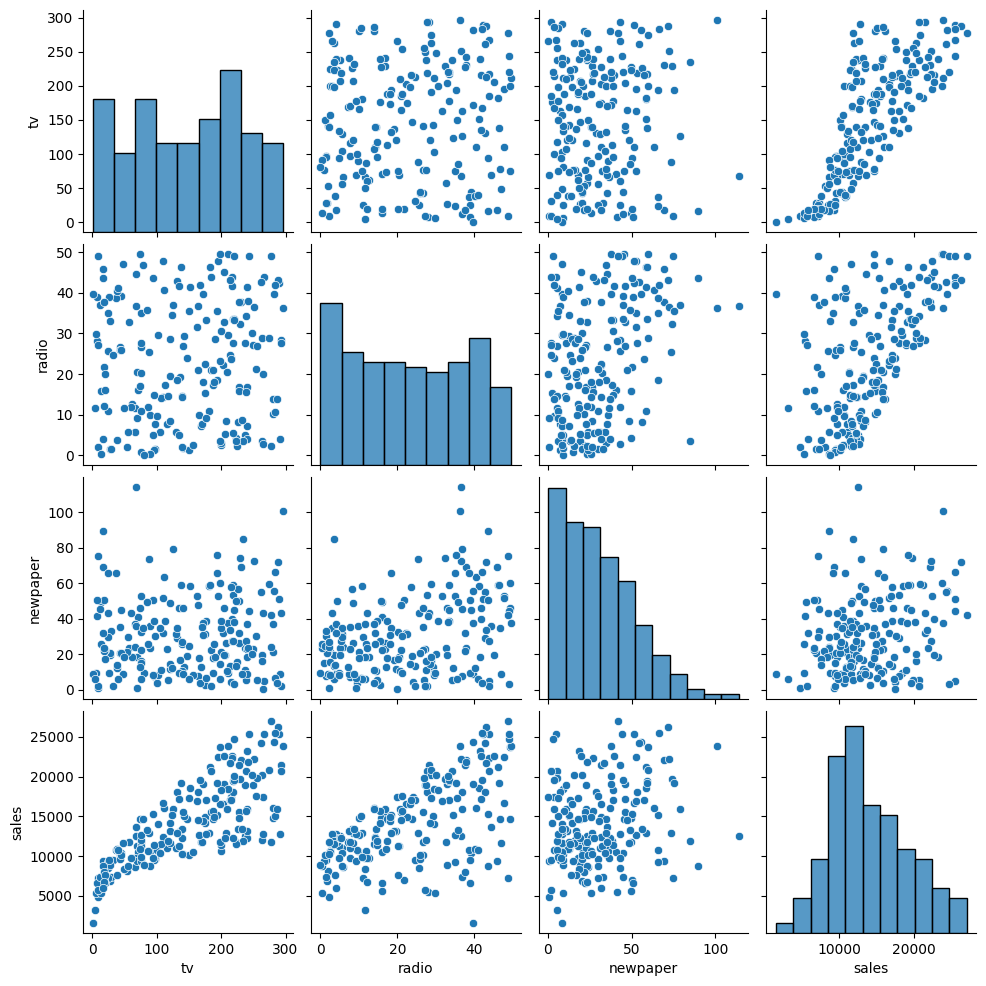

In [12]:
sns.pairplot(df)

<Axes: >

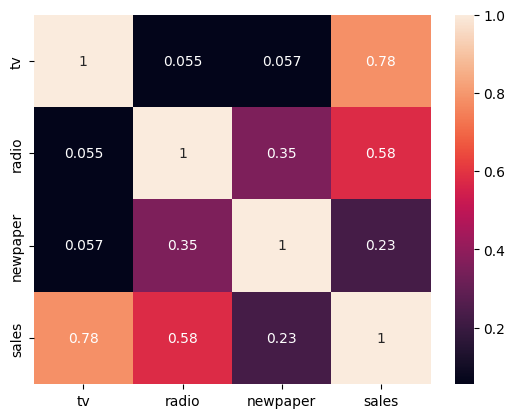

In [13]:
sns.heatmap(df.corr(), annot=True)

## Modelado

Voy a usar las variables ```tv```, ```radio``` y ```newpaper``` como predictoras, aunque esta última no tiene mucha correlación lineal con el target ```sales```. Después la quitaremos para ver si mejora el modelo. 

### Modelo lineal

In [21]:
#Funcion creada a manija para no escribir lo mismo 4856385639 veces
def do_linear_regression(X, y, test_size=0.3, poly=1):    
    # Partición de los datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    #Escalado
    X_scaler = MinMaxScaler()
    X_train_s = X_scaler.fit_transform(X_train)
    X_test_s = X_scaler.transform(X_test)

    #Regresión polinómica
    if poly > 1:
        poly_features = PolynomialFeatures(degree=poly)
        X_train_s = poly_features.fit_transform(X_train_s)
        X_test_s = poly_features.transform(X_test_s)
    
    #Creación y entrenamiento del modelo
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_s, y_train)

    #Coeficientes
    print(f'Coeficientes: {lin_reg.coef_}')
    print()
    
    #Resultados
    print('Resultados:')
    print(f'r2_train: {lin_reg.score(X_train_s, y_train)}')
    print(f'r2_test: {lin_reg.score(X_test_s, y_test)}')
    print()
    
    #Métricas
    train_predictions = lin_reg.predict(X_train_s)
    test_predictions = lin_reg.predict(X_test_s)
    print('Métricas:')
    print("MAE:", mean_absolute_error(y_test, test_predictions))
    print("MAPE:", mean_absolute_percentage_error(y_test, test_predictions))
    print("MSE_train:", mean_squared_error(y_train, train_predictions))
    print("MSE_test:", mean_squared_error(y_test, test_predictions))
    print("RMSE_train:", np.sqrt(mean_squared_error(y_train, train_predictions)))
    print("RMSE_test:", np.sqrt(mean_squared_error(y_test, test_predictions)))
    print()
    
    #Visualizaciones
    print('Visualizaciones:')
    plt.scatter(y_test, test_predictions)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--')
    
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.title("Predicción vs Real")
    plt.show()

    residuals = y_test - test_predictions
    plt.scatter(test_predictions, residuals)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Predicciones")
    plt.ylabel("Error (residual)")
    plt.title("Residuals vs Predicción")
    plt.show()

    sns.histplot(residuals, kde=True)
    plt.title("Distribución de errores")
    plt.show()

Coeficientes: [13028.32937912  9884.65984619   692.37469356]

Resultados:
r2_train: 0.9055159502227753
r2_test: 0.8609466508230367

Métricas:
MAE: 1511.6692224549088
MAPE: 0.16298720118158344
MSE_train: 2479355.1789057874
MSE_test: 3796797.2367152227
RMSE_train: 1574.5968305905444
RMSE_test: 1948.5372043446393

Visualizaciones:


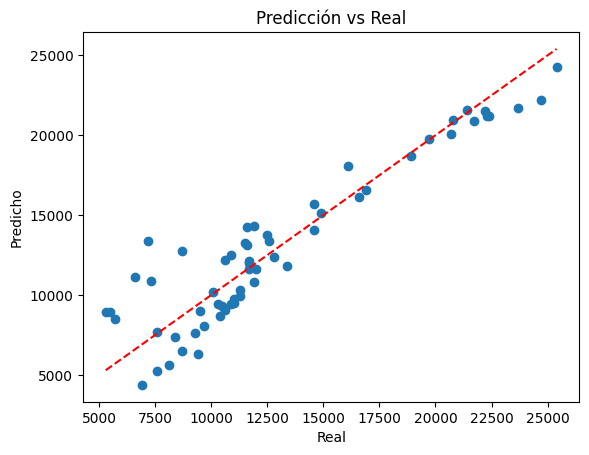

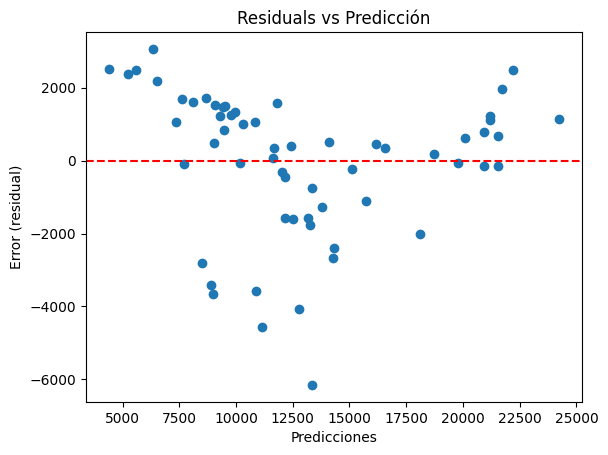

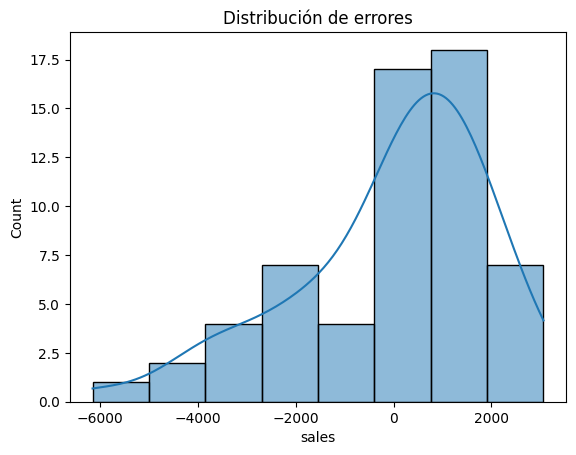

In [22]:
do_linear_regression(df[['tv','radio','newpaper']], df['sales'])

Coeficientes: [13045.20858089  9337.68520995]

Resultados:
r2_train: 0.9099038149712263
r2_test: 0.874329180902595

Métricas:
MAE: 1456.6767886793523
MAPE: 0.22125601191577035
MSE_train: 2196716.173753058
MSE_test: 4196588.148443585
RMSE: 2048.5575775270718

Visualizaciones:


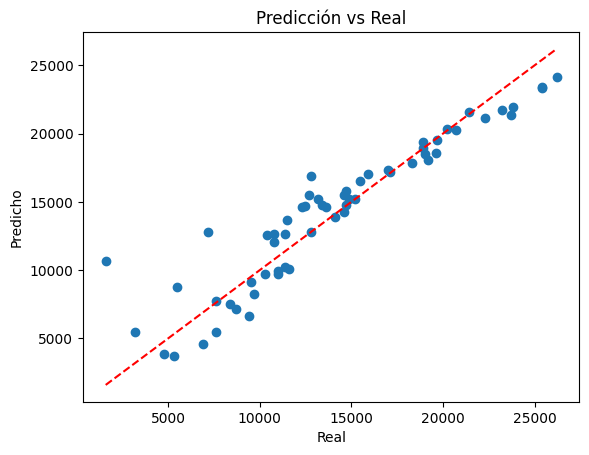

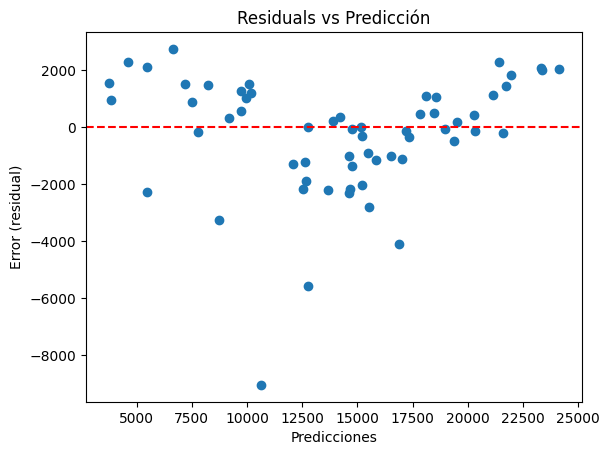

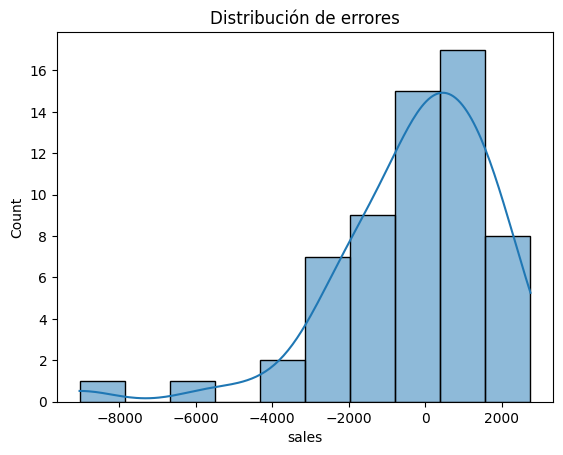

In [16]:
do_linear_regression(df[['tv','radio']], df['sales']) 

Coeficientes: [13541.65715771]

Resultados:
r2_train: 0.6188194962790379
r2_test: 0.5986534873755731

Métricas:
MAE: 2958.611388466011
MAPE: 0.28933250750636863
MSE_train: 9293904.923674127
MSE_test: 13402363.654472375
RMSE: 3660.9238799068708

Visualizaciones:


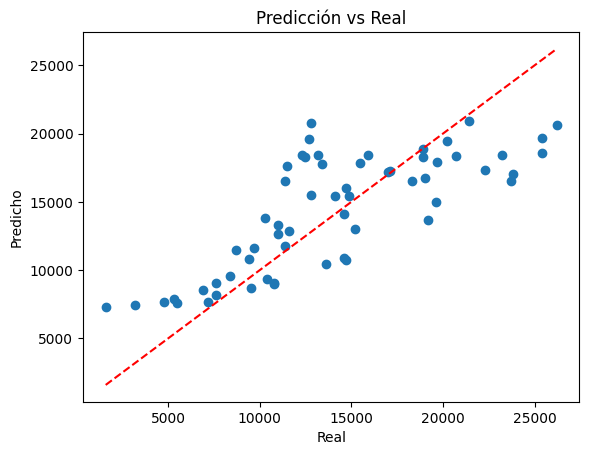

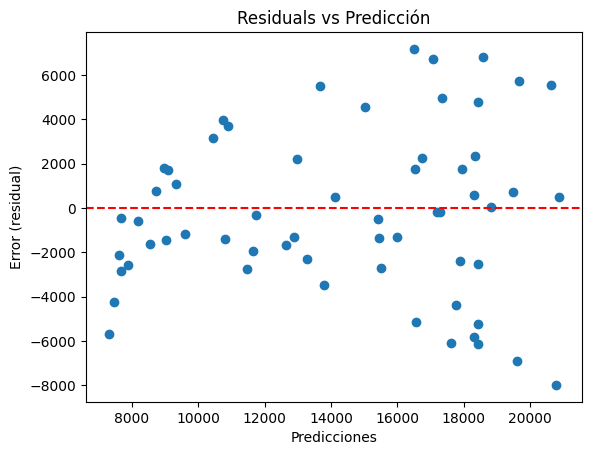

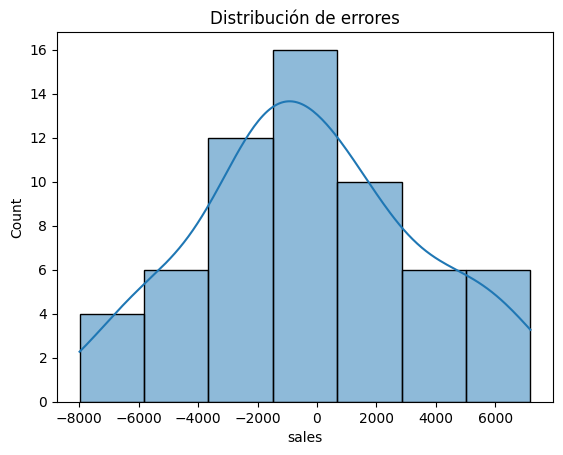

In [17]:
do_linear_regression(df[['tv']], df['sales']) 

Al quitar la variable ```newpaper``` conseguimos un modelo mejor ya que obtenemos prácticamente la misma precisión y menor MSE con una variable menos, eliminando complejidad. Se puede ver en los coeficientes que no tenia demasiado peso en comparación con ```tv``` y ```radio```, pero hay que probarlo comparando métricas aun así.

### Modelos Polinómicos

Coeficientes: [    0.         15462.99102111  1409.90370055 -9577.06649108
 15082.44088093   833.71553993]

Resultados:
r2_train: 0.9848135295751911
r2_test: 0.987063679686526

Métricas:
MAE: 496.2708612036447
MAPE: 0.04969687200790574
MSE_train: 398508.0464462237
MSE_test: 353221.159433951
RMSE: 594.3241198487161

Visualizaciones:


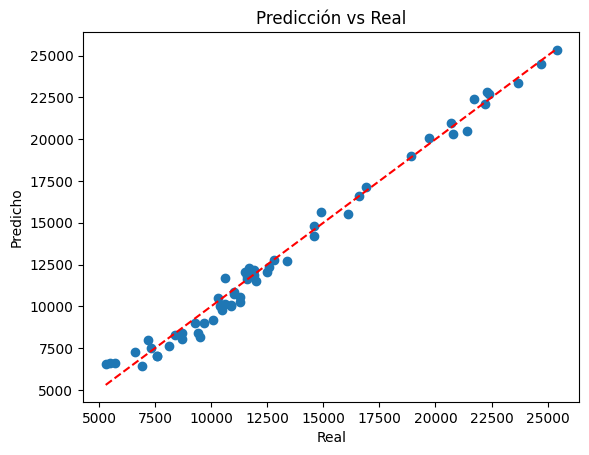

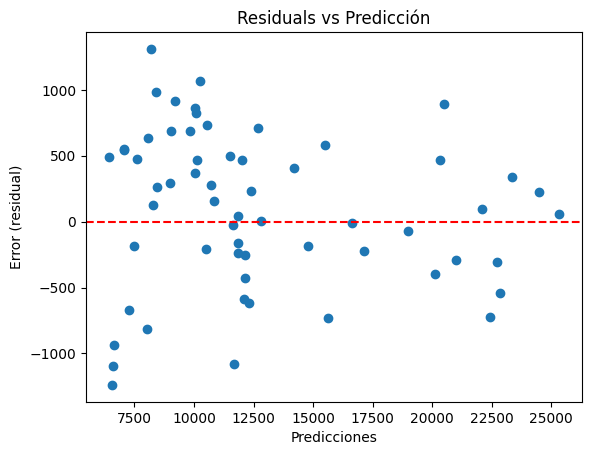

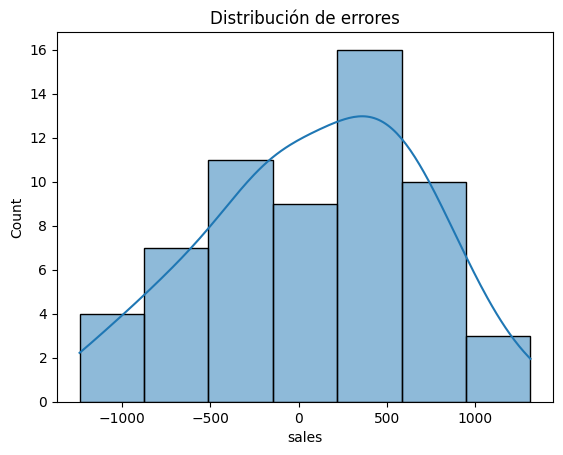

In [123]:
do_linear_regression(df[['tv','radio']], df['sales'], poly=2) 

Coeficientes: [     0.          25491.37593613   2094.28368528 -36339.26212577
  17609.18746263  -1162.10073558  18565.72348804  -2382.12897284
    -95.15426204    987.89801955]

Resultados:
r2_train: 0.9894605193067869
r2_test: 0.9940280689634928

Métricas:
MAE: 311.5259356769779
MAPE: 0.029912061996538362
MSE_train: 276566.4268340263
MSE_test: 163061.23794550684
RMSE: 403.8084173782251

Visualizaciones:


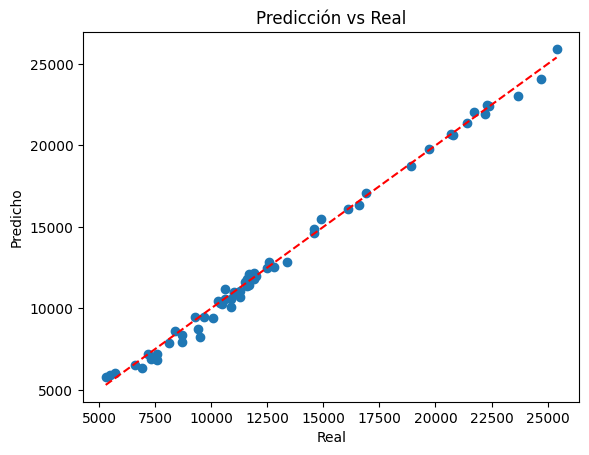

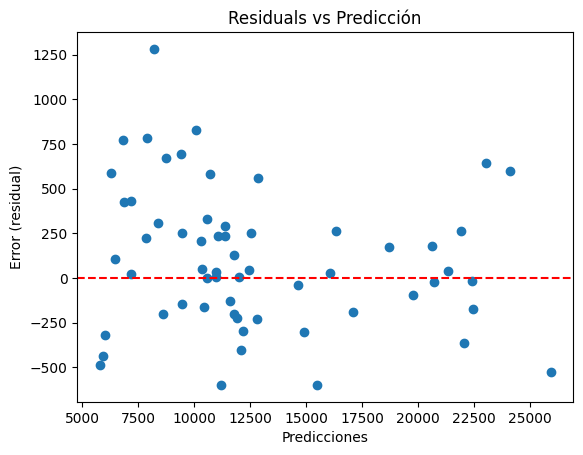

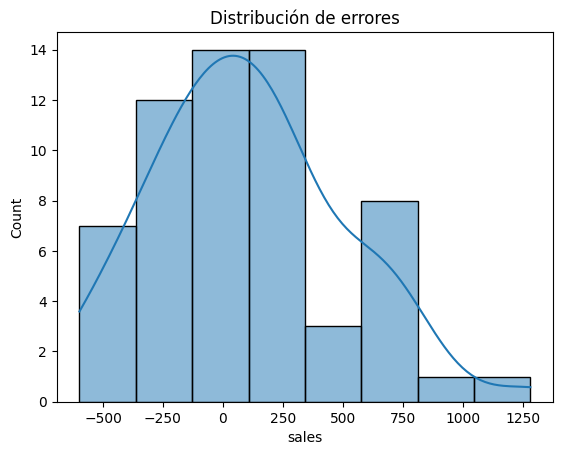

In [124]:
do_linear_regression(df[['tv','radio']], df['sales'], poly=3) 

Coeficientes: [      0.           41424.90795096     712.90855873 -114228.92009333
   28243.07969972   -1484.35679089  143468.44143428  -20925.12640014
   -4842.73853595    3896.96882377  -63452.72537673   10109.70704762
    2786.94814312    1125.48560615   -2031.72535292]

Resultados:
r2_train: 0.9924485636536141
r2_test: 0.9924895979528264

Métricas:
MAE: 361.98554942251246
MAPE: 0.03428869332119964
MSE_train: 198157.17952113427
MSE_test: 205068.58632393845
RMSE: 452.8449914970226

Visualizaciones:


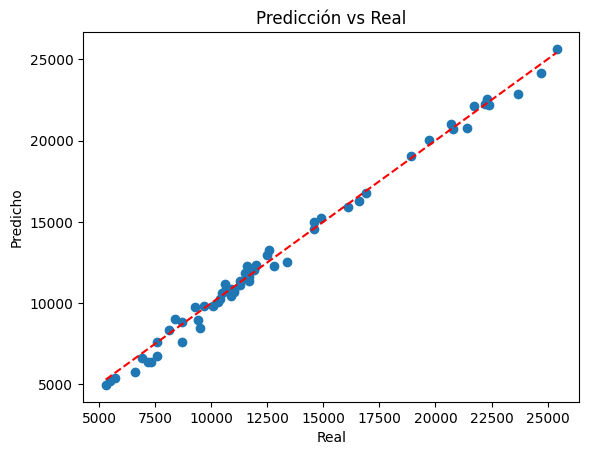

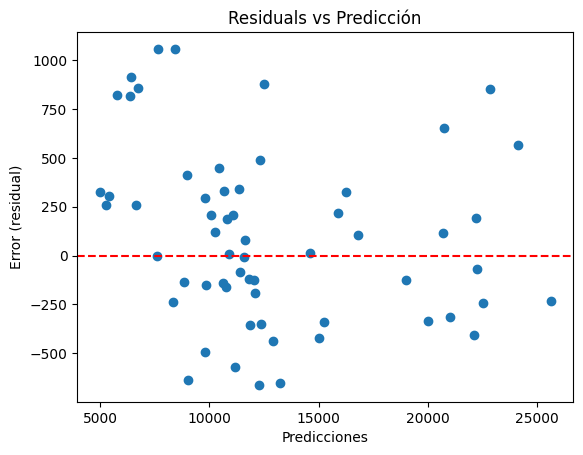

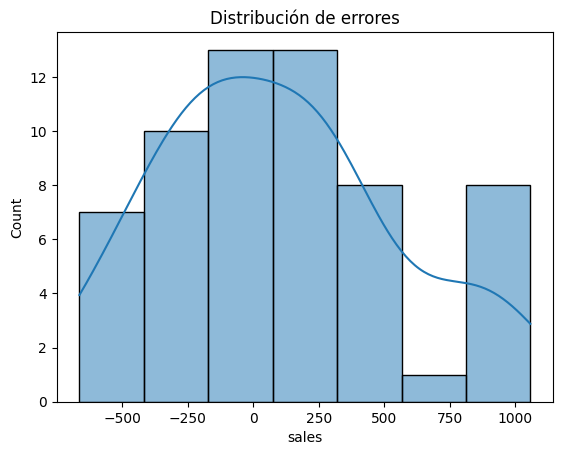

In [125]:
do_linear_regression(df[['tv','radio']], df['sales'], poly=4) 

## Resultados

He probado con distintos splits de datos y me salen diferentes resultados a veces overfiting y a veces no y no se como gestionarlo.